# Scenario 2 analysis

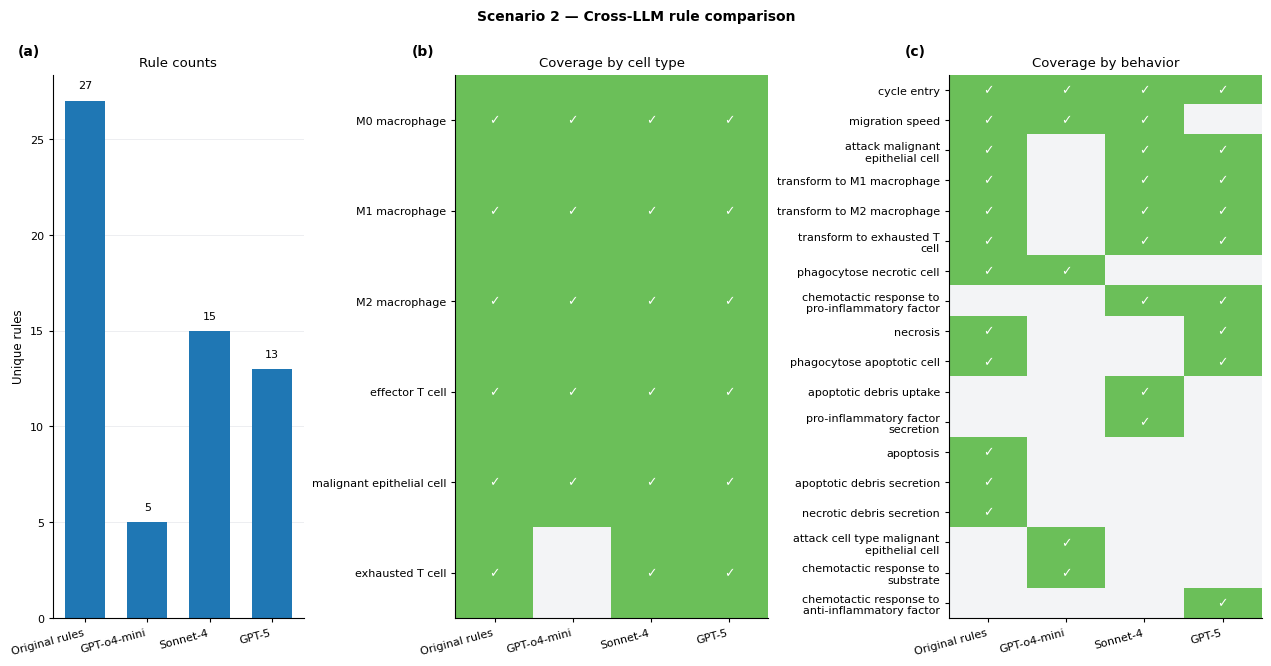

Saved: outputs/figures/scenario2_rules_dashboard_light.pdf and outputs/figures/scenario2_rules_dashboard_light.png


In [1]:
# === Cross-LLM Rules Dashboard — light, Nature-friendly styling ===
# Panels: (a) Unique rule counts  (b) Coverage by cell type  (c) Coverage by behavior

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import textwrap

# ---- INPUT ----
output_gpt5 =  "Gpt_5/Scenario_2/cell_rules_auto.csv"
output_sonnet4 = "Sonnet_4/Scenario_2/cell_rules_enhanced.csv"
output_gpt_o4 = "Gpt_o4_mini/Scenario_2/cell_rules_updated.csv"
original_rules = "cell_rules.csv"

MODEL_NAMES = {
    original_rules: "Original rules",
    output_gpt_o4:  "GPT-o4-mini",
    output_sonnet4: "Sonnet-4",
    output_gpt5:    "GPT-5"
}
HAS_HEADER       = False
TOPK_CELLTYPES   = 8     # reduce if labels still feel crowded
TOPK_BEHAVIORS   = 22
MAX_LABEL_WIDTH  = 26
SAVE_BASENAME    = "outputs/figures/scenario2_rules_dashboard_light"

# ---- STYLE ----
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 600,
})

# palette (closer to your original)
ACCENT  = "#1f77b4"   # bars
PRESENT = "#6bbf59"   # soft green (was darker before)
ABSENT  = "#f3f4f6"   # very light gray
CHECK   = "white"

# ---- LOAD ----
def load_rules(path: str, model_name: str, has_header=False) -> pd.DataFrame:
    df = pd.read_csv(path, header=None if not has_header else 0)
    if df.shape[1] < 4:
        raise ValueError(f"{path} has only {df.shape[1]} columns; expected ≥4.")
    df = df.iloc[:, :4].copy()
    df.columns = ["cell_type", "signal", "direction", "behavior"]
    for c in df.columns:
        df[c] = (df[c].astype(str)
                        .str.strip()
                        .str.replace(r"\s+", " ", regex=True))
    df["model"] = model_name
    df["rule_key"] = list(zip(df["cell_type"].str.lower(),
                              df["signal"].str.lower(),
                              df["direction"].str.lower(),
                              df["behavior"].str.lower()))
    df = df.drop_duplicates(subset=["rule_key"])
    return df

frames = [load_rules(Path(p), MODEL_NAMES[p], HAS_HEADER) for p in MODEL_NAMES]
data = pd.concat(frames, ignore_index=True)
models = list(MODEL_NAMES.values())

# ---- COVERAGE MATRICES ----
def presence_matrix(df: pd.DataFrame, item_col: str, topk: int) -> pd.DataFrame:
    counts = (df.groupby([item_col, "model"])["rule_key"]
                .nunique()
                .reset_index(name="n"))
    top_items = (counts.groupby(item_col)["n"].sum()
                 .sort_values(ascending=False).head(topk).index.tolist())
    counts = counts[counts[item_col].isin(top_items)]
    pres = counts.pivot(index=item_col, columns="model", values="n").fillna(0).astype(int)
    pres = (pres > 0).astype(int)
    pres["__sum"] = pres.sum(axis=1)
    pres = pres.sort_values(["__sum", *pres.columns[:-1]], ascending=[False, *([True]*len(models))])
    pres = pres.drop(columns="__sum").reindex(columns=models)
    return pres

pres_cell = presence_matrix(data, "cell_type", TOPK_CELLTYPES)
pres_beh  = presence_matrix(data, "behavior",  TOPK_BEHAVIORS)

# ---- UTILS ----
def wrap_labels(labels, width=24):
    return ["\n".join(textwrap.wrap(str(s), width=width, break_long_words=False)) for s in labels]

def panel_tag(ax, tag):
    ax.text(-0.14, 1.03, tag, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=10, fontweight="bold")

# Slightly taller figure to reduce crowding
fig = plt.figure(figsize=(12.6, 6.2), constrained_layout=True)
gs  = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1.0, 1.25, 1.25])

# (a) counts
ax0 = fig.add_subplot(gs[0,0])
counts_per_model = (data.groupby("model")["rule_key"].nunique().reindex(models))
bars = ax0.bar(counts_per_model.index, counts_per_model.values, color=ACCENT, width=0.65)
ax0.set_ylabel("Unique rules")
ax0.set_title("Rule counts", pad=6)
ax0.yaxis.grid(True, color="#e5e7eb", linewidth=0.6, alpha=0.8)
ax0.set_axisbelow(True)
for t in ax0.get_xticklabels():
    t.set_rotation(15)
    t.set_ha("right")
for r in bars:
    ax0.text(r.get_x()+r.get_width()/2, r.get_height()+max(0.5, r.get_height()*0.02),
             f"{int(r.get_height())}", ha="center", va="bottom", fontsize=8)
panel_tag(ax0, "(a)")

# binary heatmap helper (green/gray + checkmarks)
def binary_heatmap(ax, pres_df: pd.DataFrame, title: str):
    ax.set_title(title, pad=6)
    cmap = ListedColormap([ABSENT, PRESENT])
    im = ax.imshow(pres_df.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    ax.set_yticks(range(len(pres_df.index)))
    ax.set_yticklabels(wrap_labels(pres_df.index, width=MAX_LABEL_WIDTH))
    ax.set_xticks(range(len(pres_df.columns)))
    ax.set_xticklabels(pres_df.columns, rotation=0)
    # minimal box, no clutter
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    # add checkmarks only where present
    for i in range(pres_df.shape[0]):
        for j in range(pres_df.shape[1]):
            if pres_df.iat[i, j] == 1:
                ax.text(j, i, "✓", ha="center", va="center",
                        fontsize=9, color=CHECK, fontweight="bold")

# (b) cell types
ax1 = fig.add_subplot(gs[0,1])
binary_heatmap(ax1, pres_cell, "Coverage by cell type")
panel_tag(ax1, "(b)")
for t in ax1.get_xticklabels():
    t.set_rotation(15)
    t.set_ha("right")

# (c) behaviors
ax2 = fig.add_subplot(gs[0,2])
binary_heatmap(ax2, pres_beh, "Coverage by behavior")
panel_tag(ax2, "(c)")
for t in ax2.get_xticklabels():
    t.set_rotation(15)
    t.set_ha("right")

fig.suptitle("Scenario 2 — Cross-LLM rule comparison", y=1.05, fontsize=10, fontweight="bold")
plt.show()

# Save vector + PNG
Path(f"{SAVE_BASENAME}.pdf").write_bytes(b"")  # ensure path exists on some envs
fig.savefig(f"{SAVE_BASENAME}.pdf", bbox_inches="tight")
fig.savefig(f"{SAVE_BASENAME}.png", bbox_inches="tight")
print("Saved:", f"{SAVE_BASENAME}.pdf", "and", f"{SAVE_BASENAME}.png")


Total unique rules across all models: 48


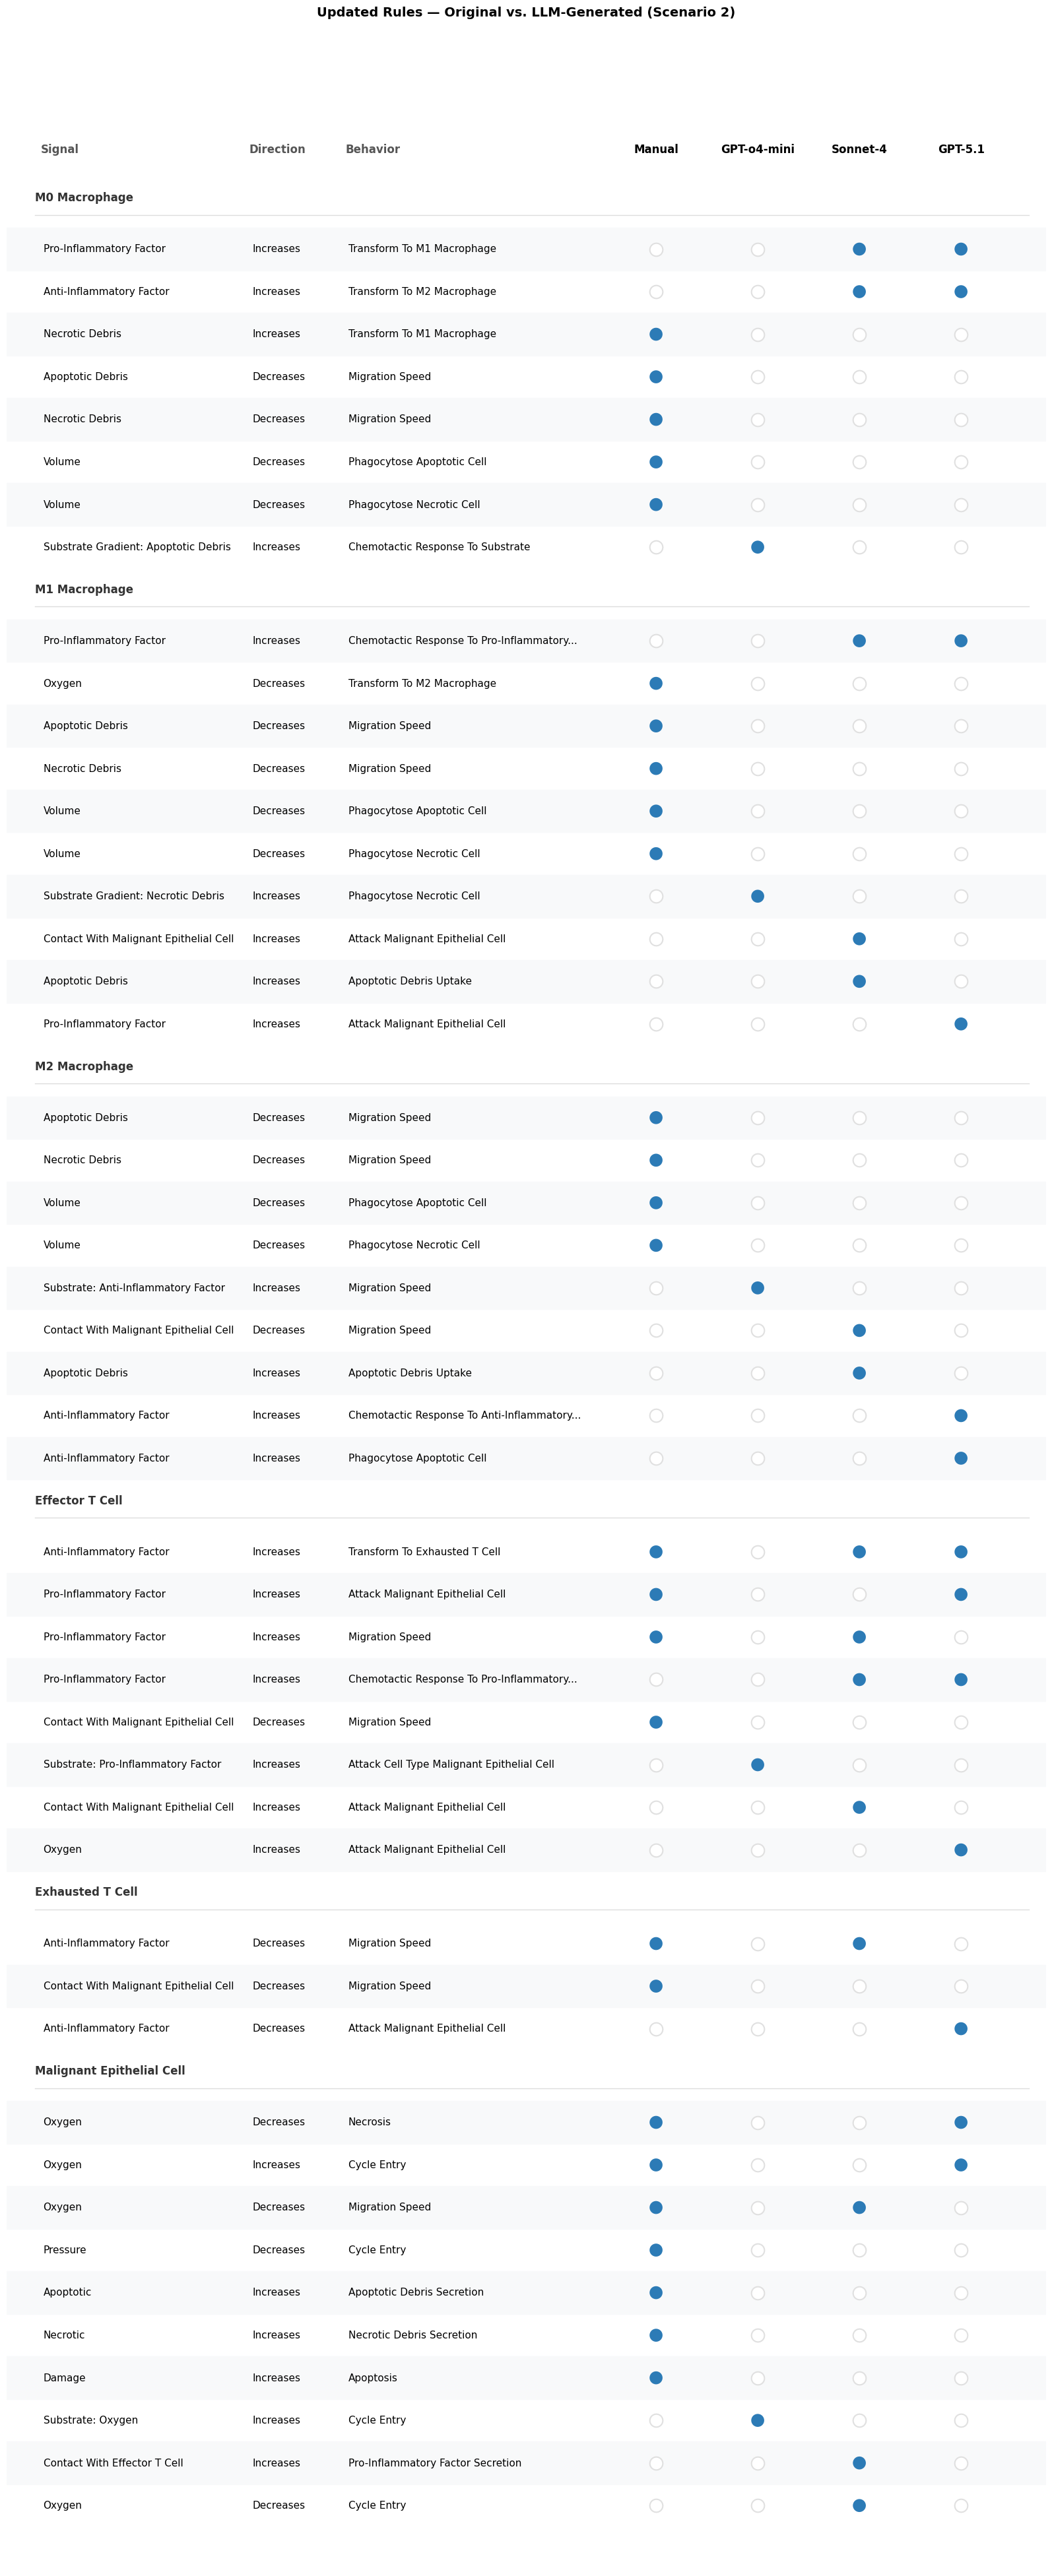

Saved: outputs/figures/rules_table_updated.pdf / .png
LaTeX table written to: outputs/tables/rules_table_updated.tex


In [2]:

# === Updated Rules Matrix — Dot-matrix style (matching Scenario 1 figure) ===
# Filled blue dots = rule present, open circles = absent.
# Grouped by cell type with bold section headers.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# ---- FILE PATHS ----
FILES = {
    "Manual":      "cell_rules.csv",
    "GPT-o4-mini": "Gpt_o4_mini/Scenario_2/cell_rules_updated.csv",
    "Sonnet-4":    "Sonnet_4/Scenario_2/cell_rules_enhanced.csv",
    "GPT-5.1":       "Gpt_5/Scenario_2/cell_rules_auto.csv",
}
LATEX_OUT = "outputs/tables/rules_table_updated.tex"

# ---- STYLE (matches Scenario 1 figure) ----
COLOR_PRIMARY = "#2C7BB6"
COLOR_MUTED   = "#E0E0E0"
FONT_FAMILY   = "sans-serif"

# ---- LOAD & NORMALISE ----
def load_rules(path, model_name):
    df = pd.read_csv(path, header=None)
    df = df.iloc[:, :4].copy()
    df.columns = ["cell_type", "signal", "direction", "behavior"]
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    df["model"] = model_name
    df["rule_key"] = list(zip(
        df["cell_type"].str.lower(),
        df["signal"].str.lower(),
        df["direction"].str.lower(),
        df["behavior"].str.lower(),
    ))
    return df.drop_duplicates(subset=["rule_key"])

frames = [load_rules(p, m) for m, p in FILES.items()]
data   = pd.concat(frames, ignore_index=True)
models = list(FILES.keys())

# ---- BUILD PRESENCE MATRIX ----
all_rules = (data[["cell_type", "signal", "direction", "behavior", "rule_key"]]
             .drop_duplicates(subset=["rule_key"]))

m_keys_cache = {m: set(data[data["model"] == m]["rule_key"]) for m in models}

rows = []
for _, r in all_rules.iterrows():
    entry = {k: r[k] for k in ["cell_type", "signal", "direction", "behavior"]}
    for m in models:
        entry[m] = 1 if r["rule_key"] in m_keys_cache[m] else 0
    rows.append(entry)

matrix = pd.DataFrame(rows)
matrix["n_models"] = matrix[models].sum(axis=1)
matrix = (matrix
          .sort_values(["cell_type", "n_models"], ascending=[True, False])
          .reset_index(drop=True))

print(f"Total unique rules across all models: {len(matrix)}")

# ---- LAYOUT: compute y positions ----
y_positions      = {}
header_positions = {}

current_y = 0
prev_ct   = None

for i, (_, row) in enumerate(matrix.iterrows()):
    ct = row["cell_type"]
    if ct != prev_ct:
        header_positions[ct] = current_y
        current_y -= 1.2
        prev_ct = ct
    y_positions[i] = current_y
    current_y -= 1.0

# ---- FIGURE ----
plt.rcParams["font.family"] = FONT_FAMILY

fig_h = max(10, abs(current_y) * 0.65 + 3)
fig, ax = plt.subplots(figsize=(16, fig_h))
ax.axis("off")

# x layout — Signal | Direction | Behavior (wider) | Models (narrower spacing)
x_header = 0
x_sig    = 0.1    # signal left-aligned
x_dir    = 3.8    # direction left-aligned
x_beh    = 5.5    # behavior left-aligned (wider: models pushed to 11.0+)
x_positions = {model: 11.0 + i * 1.8 for i, model in enumerate(models)}

# Alternating row backgrounds
for i, y in y_positions.items():
    if i % 2 == 0:
        ax.axhspan(y - 0.5, y + 0.5, color="#F8F9FA", zorder=0)

# Column headers
for lbl, x in zip(["Signal", "Direction", "Behavior"], [x_sig, x_dir, x_beh]):
    ax.text(x, 1.0, lbl, ha="left", va="bottom", fontsize=12,
            fontweight="bold", color="#555555")
for model, x in x_positions.items():
    ax.text(x, 1.0, model, ha="center", va="bottom", fontsize=12, fontweight="bold")

# Section headers (cell types) with divider lines
for ct, y in header_positions.items():
    ax.text(x_header, y, ct.title(), ha="left", va="center",
            fontsize=12, fontweight="bold", color="#333333")
    ax.plot([x_header, max(x_positions.values()) + 1.2],
            [y - 0.4, y - 0.4], color="#DDDDDD", lw=1, zorder=1)

def shorten(s, n=45):
    return textwrap.shorten(s.title(), width=n, placeholder="...")

# Data rows
for i, (_, row) in enumerate(matrix.iterrows()):
    y = y_positions[i]
    ax.text(x_sig + 0.05, y, shorten(row["signal"]),   ha="left", va="center", fontsize=11)
    ax.text(x_dir + 0.05, y, row["direction"].title(), ha="left", va="center", fontsize=11)
    ax.text(x_beh + 0.05, y, shorten(row["behavior"]), ha="left", va="center", fontsize=11)

    for model, x in x_positions.items():
        if row[model] == 1:
            ax.scatter(x, y, s=200, color=COLOR_PRIMARY, edgecolors="none", zorder=3)
        else:
            ax.scatter(x, y, s=200, color="white", edgecolors=COLOR_MUTED,
                       linewidth=1.5, zorder=3)

plt.title("Updated Rules — Original vs. LLM-Generated (Scenario 2)",
          fontsize=14, fontweight="bold", pad=25, y=1.03)

ax.set_xlim(-0.5, max(x_positions.values()) + 1.5)
ax.set_ylim(current_y - 0.5, 2)

plt.tight_layout()
plt.savefig("outputs/figures/rules_table_updated.pdf", dpi=300, bbox_inches="tight")
plt.savefig("outputs/figures/rules_table_updated.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/rules_table_updated.pdf / .png")


# ---- LATEX EXPORT ----
def tex_escape(s):
    return (str(s)
            .replace("\\", "\\textbackslash ")
            .replace("&",  "\\&")
            .replace("%",  "\\%")
            .replace("_",  "\\_")
            .replace("#",  "\\#")
            .replace("$",  "\\$")
            .replace("{",  "\\{")
            .replace("}",  "\\}")
            .title())

lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    (r"\caption{Rule-by-rule comparison of updated LLM-generated rules, grouped by cell type. "
     r"\textbf{\checkmark} indicates rule is present, --- indicates absent. "
     r"The files (rules.csv) with all the rules generated by the LLMs can be found at "
     r"\url{https://github.com/marcorusc/Supp_mat_MCP_orchestrator}}"),
    r"\label{tab:rules_matrix_updated}",
    r"\small",
    r"\begin{tabular}{p{4.5cm}p{1.3cm}p{4.5cm}cccc}",
    r"\toprule",
    r"Signal & Direction & Behavior & Manual & GPT-o4-mini & Sonnet-4 & GPT-5 \\",
    r"\midrule",
]

prev_ct = None
for _, row in matrix.iterrows():
    ct = row["cell_type"]
    if ct != prev_ct:
        if prev_ct is not None:
            lines.append(r"\midrule")
        lines.append(f"\\multicolumn{{7}}{{l}}{{\\textbf{{{tex_escape(ct)}}}}} \\\\")
        lines.append(r"\midrule")
        prev_ct = ct
    sig  = tex_escape(row["signal"])
    dir_ = tex_escape(row["direction"])
    beh  = tex_escape(row["behavior"])
    cols = " & ".join(r"\checkmark" if row[m] else "---" for m in models)
    lines.append(f"{sig} & {dir_} & {beh} & {cols} \\\\")

lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
Path(LATEX_OUT).write_text("\n".join(lines))
print(f"LaTeX table written to: {LATEX_OUT}")


Rows after filtering (Manual-only rows removed): 28


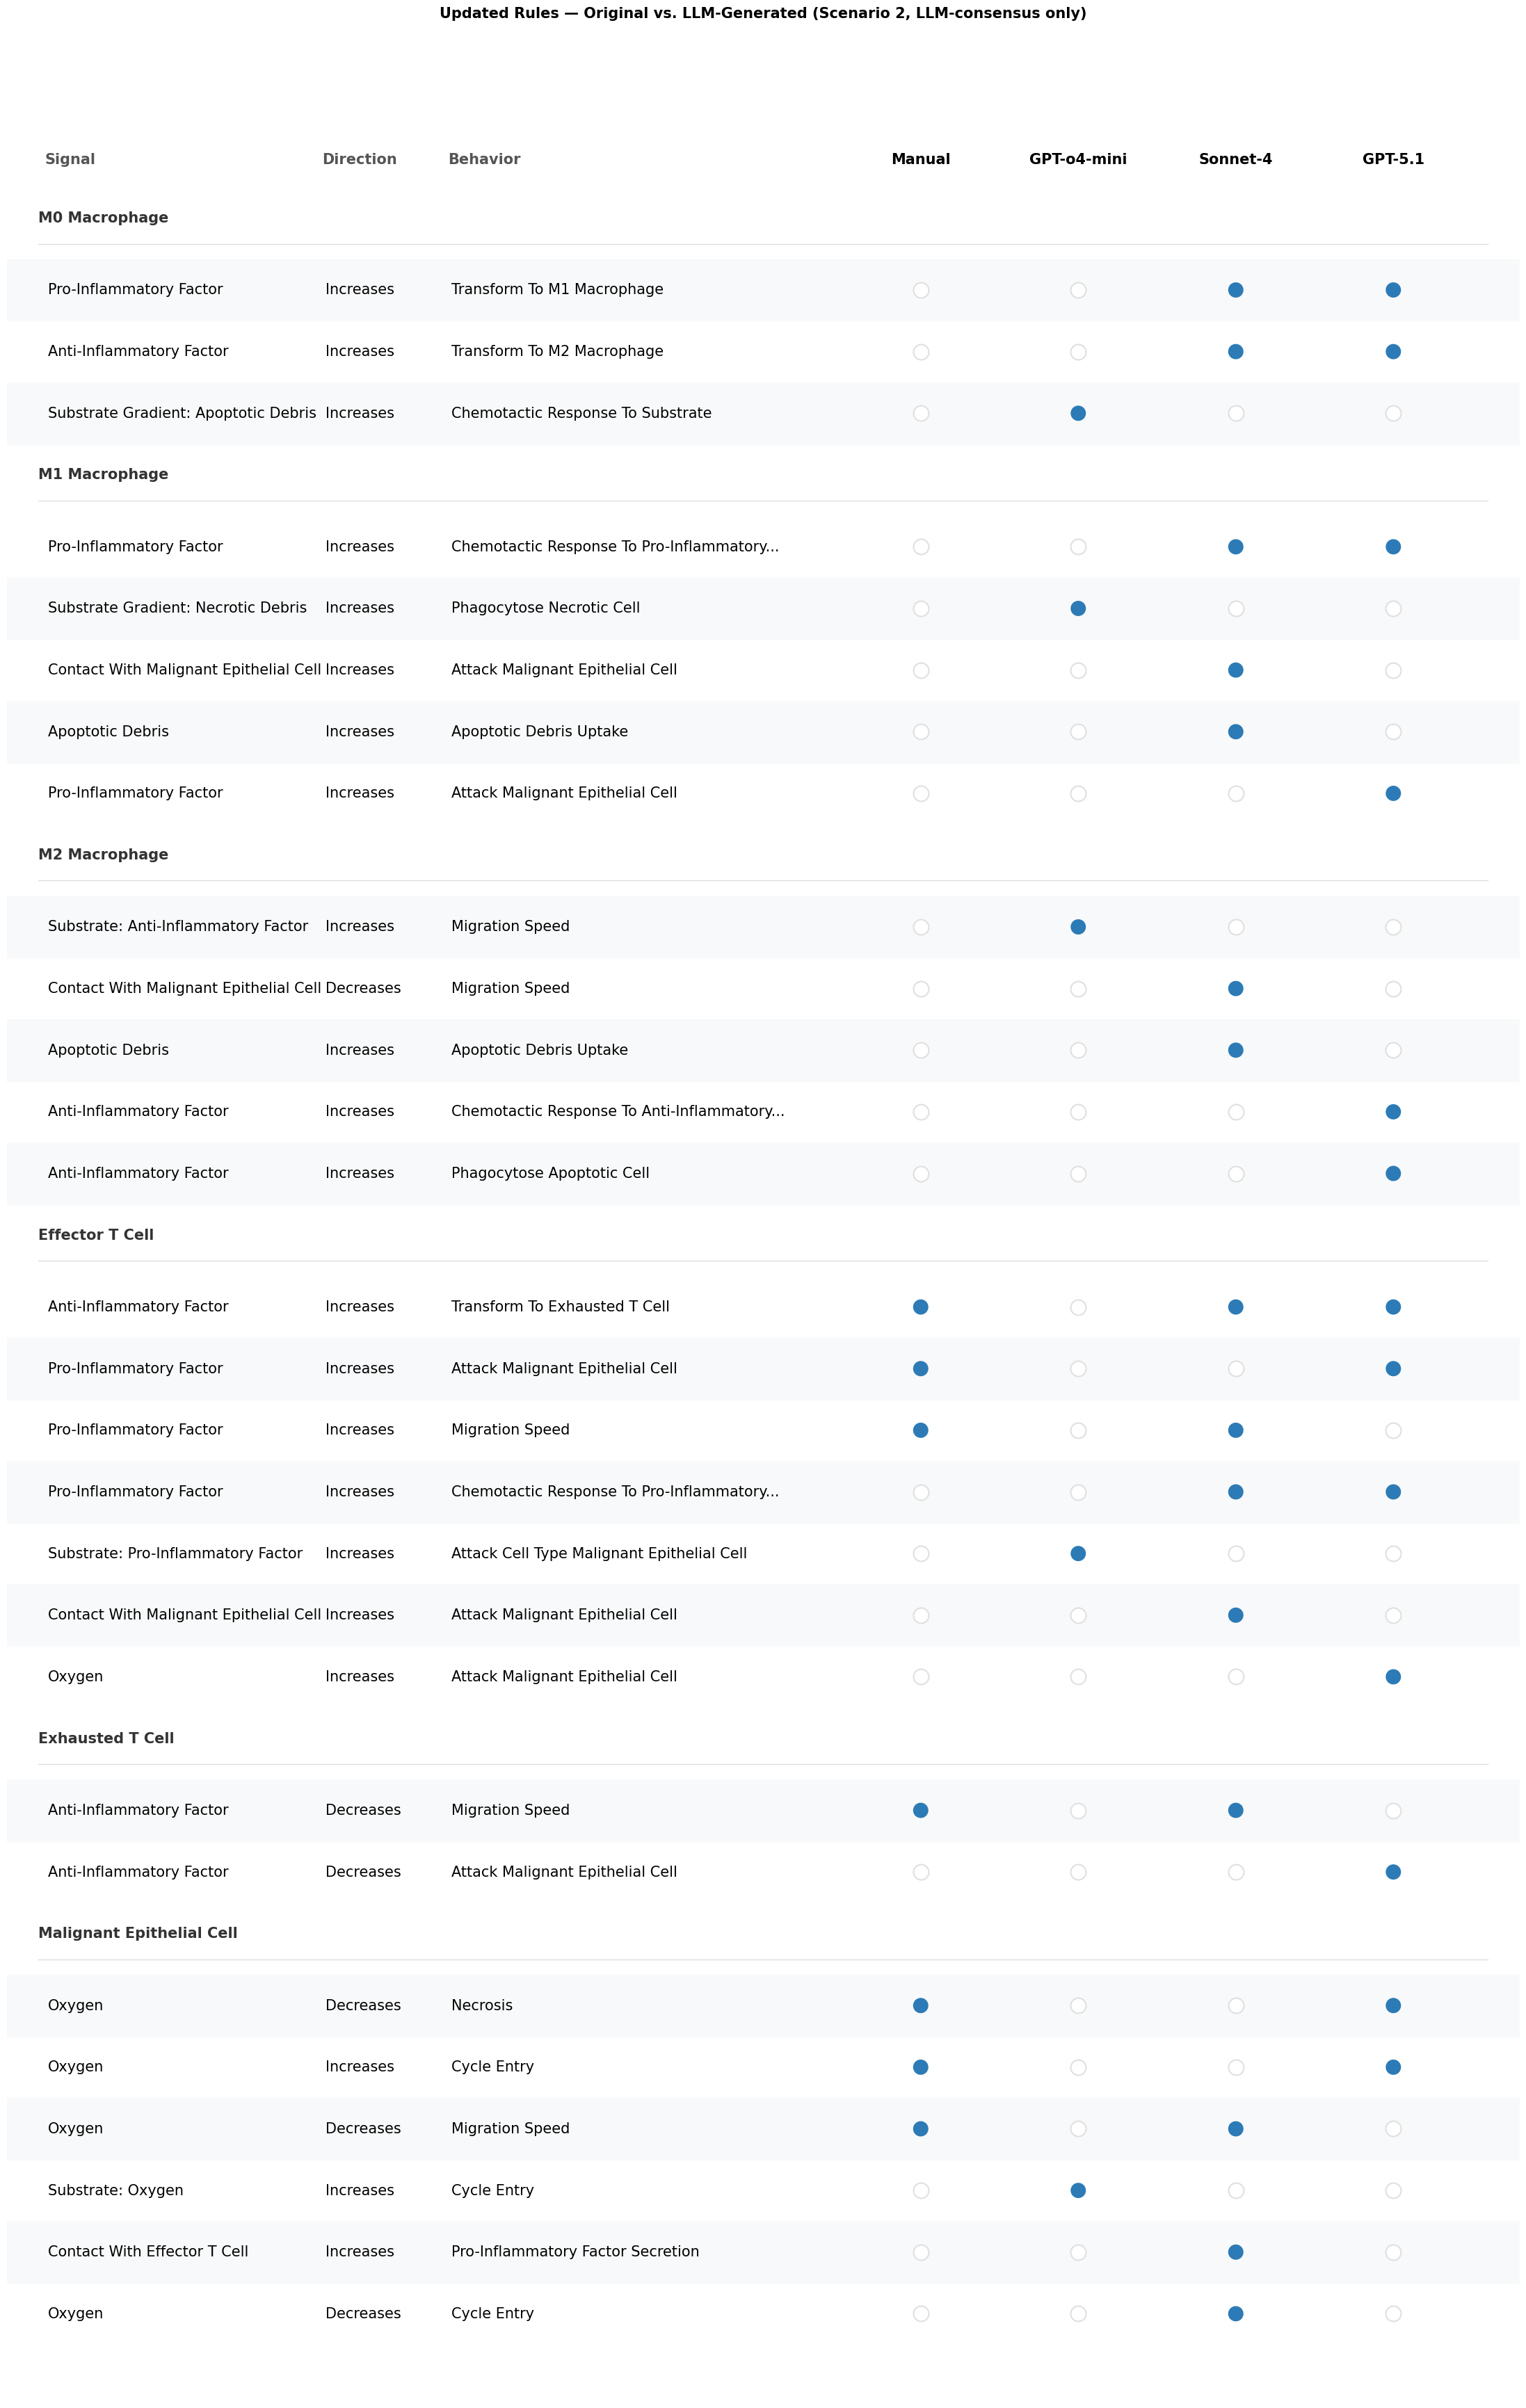

Saved: outputs/figures/rules_table_updated_filtered.pdf / .png
LaTeX table written to: outputs/tables/rules_table_updated_filtered.tex


In [3]:

# === Updated Rules Matrix — Large-font version, LLM-consensus rows only ===
# Same dot-matrix style but fontsize=15 (matching Scenario 1 PhysiCell figure).
# Rows where Manual=present but ALL three LLMs are absent are removed.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# ---- FILE PATHS ----
FILES = {
    "Manual":      "cell_rules.csv",
    "GPT-o4-mini": "Gpt_o4_mini/Scenario_2/cell_rules_updated.csv",
    "Sonnet-4":    "Sonnet_4/Scenario_2/cell_rules_enhanced.csv",
    "GPT-5.1":       "Gpt_5/Scenario_2/cell_rules_auto.csv",
}
LATEX_OUT_FILTERED = "outputs/tables/rules_table_updated_filtered.tex"

COLOR_PRIMARY = "#2C7BB6"
COLOR_MUTED   = "#E0E0E0"
FONT_FAMILY   = "sans-serif"
FONT_SZ       = 15   # matches the Scenario 1 reference figure

# ---- LOAD & NORMALISE ----
def load_rules_v2(path, model_name):
    df = pd.read_csv(path, header=None)
    df = df.iloc[:, :4].copy()
    df.columns = ["cell_type", "signal", "direction", "behavior"]
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    df["model"] = model_name
    df["rule_key"] = list(zip(
        df["cell_type"].str.lower(),
        df["signal"].str.lower(),
        df["direction"].str.lower(),
        df["behavior"].str.lower(),
    ))
    return df.drop_duplicates(subset=["rule_key"])

frames = [load_rules_v2(p, m) for m, p in FILES.items()]
data2   = pd.concat(frames, ignore_index=True)
models  = list(FILES.keys())
llm_models = [m for m in models if m != "Manual"]

m_keys2 = {m: set(data2[data2["model"] == m]["rule_key"]) for m in models}

all_rules2 = (data2[["cell_type", "signal", "direction", "behavior", "rule_key"]]
              .drop_duplicates(subset=["rule_key"]))

rows2 = []
for _, r in all_rules2.iterrows():
    entry = {k: r[k] for k in ["cell_type", "signal", "direction", "behavior"]}
    for m in models:
        entry[m] = 1 if r["rule_key"] in m_keys2[m] else 0
    rows2.append(entry)

matrix2 = pd.DataFrame(rows2)
matrix2["n_models"] = matrix2[models].sum(axis=1)
matrix2 = (matrix2
           .sort_values(["cell_type", "n_models"], ascending=[True, False])
           .reset_index(drop=True))

# ---- FILTER: remove rows where Manual=1 but all LLMs are absent ----
llm_sum = matrix2[llm_models].sum(axis=1)
mask = ~((matrix2["Manual"] == 1) & (llm_sum == 0))
matrix2 = matrix2[mask].reset_index(drop=True)

print(f"Rows after filtering (Manual-only rows removed): {len(matrix2)}")

# ---- LAYOUT ----
y_positions2      = {}
header_positions2 = {}
current_y2 = 0
prev_ct    = None

for i, (_, row) in enumerate(matrix2.iterrows()):
    ct = row["cell_type"]
    if ct != prev_ct:
        header_positions2[ct] = current_y2
        current_y2 -= 1.4
        prev_ct = ct
    y_positions2[i] = current_y2
    current_y2 -= 1.2

# ---- FIGURE ----
plt.rcParams["font.family"] = FONT_FAMILY

fig_h = max(12, abs(current_y2) * 0.75 + 3)
fig, ax = plt.subplots(figsize=(22, fig_h))
ax.axis("off")

x_header = 0
x_sig    = 0.1
x_dir    = 4.5
x_beh    = 6.5
x_positions2 = {model: 14.0 + i * 2.5 for i, model in enumerate(models)}

# Alternating row backgrounds
for i, y in y_positions2.items():
    if i % 2 == 0:
        ax.axhspan(y - 0.6, y + 0.6, color="#F8F9FA", zorder=0)

# Column headers
for lbl, x in zip(["Signal", "Direction", "Behavior"], [x_sig, x_dir, x_beh]):
    ax.text(x, 1.0, lbl, ha="left", va="bottom", fontsize=FONT_SZ,
            fontweight="bold", color="#555555")
for model, x in x_positions2.items():
    ax.text(x, 1.0, model, ha="center", va="bottom", fontsize=FONT_SZ, fontweight="bold")

# Section headers (cell types) with divider lines
for ct, y in header_positions2.items():
    ax.text(x_header, y, ct.title(), ha="left", va="center",
            fontsize=FONT_SZ, fontweight="bold", color="#333333")
    ax.plot([x_header, max(x_positions2.values()) + 1.5],
            [y - 0.5, y - 0.5], color="#DDDDDD", lw=1, zorder=1)

def shorten(s, n=45):
    return textwrap.shorten(s.title(), width=n, placeholder="...")

for i, (_, row) in enumerate(matrix2.iterrows()):
    y = y_positions2[i]
    ax.text(x_sig + 0.05, y, shorten(row["signal"]),   ha="left", va="center", fontsize=FONT_SZ)
    ax.text(x_dir + 0.05, y, row["direction"].title(), ha="left", va="center", fontsize=FONT_SZ)
    ax.text(x_beh + 0.05, y, shorten(row["behavior"]), ha="left", va="center", fontsize=FONT_SZ)

    for model, x in x_positions2.items():
        if row[model] == 1:
            ax.scatter(x, y, s=250, color=COLOR_PRIMARY, edgecolors="none", zorder=3)
        else:
            ax.scatter(x, y, s=250, color="white", edgecolors=COLOR_MUTED,
                       linewidth=1.5, zorder=3)

plt.title("Updated Rules — Original vs. LLM-Generated (Scenario 2, LLM-consensus only)",
          fontsize=FONT_SZ, fontweight="bold", pad=30, y=1.03)

ax.set_xlim(-0.5, max(x_positions2.values()) + 2.0)
ax.set_ylim(current_y2 - 0.5, 2)

plt.tight_layout()
plt.savefig("outputs/figures/rules_table_updated_filtered.pdf", dpi=300, bbox_inches="tight")
plt.savefig("outputs/figures/rules_table_updated_filtered.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/rules_table_updated_filtered.pdf / .png")


# ---- LATEX EXPORT ----
def tex_escape(s):
    return (str(s)
            .replace("\\", "\\textbackslash ")
            .replace("&",  "\\&")
            .replace("%",  "\\%")
            .replace("_",  "\\_")
            .replace("#",  "\\#")
            .replace("$",  "\\$")
            .replace("{",  "\\{")
            .replace("}",  "\\}")
            .title())

lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    (r"\caption{Rule-by-rule comparison of updated LLM-generated rules, grouped by cell type. "
     r"Rows present only in the manual rule set (absent from all LLM outputs) are excluded. "
     r"\textbf{\checkmark} indicates rule is present, --- indicates absent. "
     r"The files (rules.csv) with all the rules generated by the LLMs can be found at "
     r"\url{https://github.com/marcorusc/Supp_mat_MCP_orchestrator}}"),
    r"\label{tab:rules_matrix_filtered}",
    r"\small",
    r"\begin{tabular}{p{4.5cm}p{1.3cm}p{4.5cm}cccc}",
    r"\toprule",
    r"Signal & Direction & Behavior & Manual & GPT-o4-mini & Sonnet-4 & GPT-5 \\",
    r"\midrule",
]

prev_ct = None
for _, row in matrix2.iterrows():
    ct = row["cell_type"]
    if ct != prev_ct:
        if prev_ct is not None:
            lines.append(r"\midrule")
        lines.append(f"\\multicolumn{{7}}{{l}}{{\\textbf{{{tex_escape(ct)}}}}} \\\\")
        lines.append(r"\midrule")
        prev_ct = ct
    sig  = tex_escape(row["signal"])
    dir_ = tex_escape(row["direction"])
    beh  = tex_escape(row["behavior"])
    cols = " & ".join(r"\checkmark" if row[m] else "---" for m in models)
    lines.append(f"{sig} & {dir_} & {beh} & {cols} \\\\")

lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]
Path(LATEX_OUT_FILTERED).write_text("\n".join(lines))
print(f"LaTeX table written to: {LATEX_OUT_FILTERED}")
